In [1]:
# 调用包

# %%javascript 折叠命令
%matplotlib inline
# import find_motifs as fdm
from scipy import stats
import copy
import networkx as nx
from collections import Counter
from math import sqrt
from matplotlib.pyplot import MultipleLocator
from statistics import mean
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import time
import math
import json
import csv
import os
import shutil
import seaborn as sns
import numpy as np
import pandas as pd
import tempfile
# from pandas.io.json import json_normalize
from pandas.core.frame import DataFrame
import networkx as nx
from collections import deque
# 忽略警告
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
from sklearn.model_selection import train_test_split
from xgboost import plot_importance
from sklearn import preprocessing
from sklearn.utils import shuffle
#from sklearn.metrics import plot_confusion_matrix
lbl = preprocessing.LabelEncoder()
import xgboost as xgb

In [11]:
import networkx as nx
import time
from collections import deque
import copy

def Feasibility(G,edge1,edge2):
    """
    :param G:
    :param edge1:
    :param edge2:
    :return:
    """
    result= False
    hasEdge = G.has_edge(edge1[0], edge1[1])
    hasEdge1 = G.has_edge(edge2[0], edge2[1])
    hasEdge2 = G.has_edge(edge1[1], edge1[0])
    hasEdge3 = G.has_edge(edge2[1], edge2[0])

    if(hasEdge == hasEdge1  and hasEdge2 == hasEdge3):
        result=True
    return result


def Feasibility_weighted(G,G_motif,n1,n2,N1,node,hasEdge):
    """
    在无向加权网络中
    根据同构条件判断是否是要寻找的模体
    :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
    :param G_motif: 模体图,可以有向或者无向但必须与图G一致
    :param n1: 模体网络G_motif中的节点
    :param n2: 模体网络G_motif中的节点
    :param N1: 目标网络G中的节点
    :param node: 目标网络G中的节点
    :param hasEdge: n1和n2之间是否有正向边
    :return True or False: 代表是否构成模体
    """
    if hasEdge:
        if(G_motif[n1][n2]['weight'])!= (G[N1][node]['weight']):
            return False

    return True

def Feasibility_weighted_directed(G,G_motif,n1,n2,N1,node,hasEdge,hasEdge1):
    """
    根据同构条件判断是否是要寻找的模体
    :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
    :param G_motif: 模体图,可以有向或者无向但必须与图G一致
    :param n1: 模体网络G_motif中的节点
    :param n2: 模体网络G_motif中的节点
    :param N1: 目标网络G中的节点
    :param node: 目标网络G中的节点
    :param hasEdge: n1和n2之间是否有正向边
    :param hasEdge1: n2和n1之间是否有反向边
    :return True or False: 代表是否构成模体
    """
    if hasEdge1:
        if (G_motif[n2][n1]['weight'])!= (G[node][N1]['weight']):
            return False

    if hasEdge:
        if (G_motif[n1][n2]['weight'])!= (G[N1][node]['weight']):
            return False

    return True

def preSort(G_motif,G2_node_list):
    """
    预处理：排序，调整搜索顺序，将度大的放前面，这样约束越多，剪枝越多，搜索越快。
    :param G_motif:
    :param G2_node_list:
    :param n_G2:
    """
    n_G2=len(G2_node_list)
    for i in range(1,n_G2):
        for j in range(0,n_G2-i):
            if G_motif.degree(G2_node_list[j+1])>G_motif.degree(G2_node_list[j]):
                t=G2_node_list[j]
                G2_node_list[j]=G2_node_list[j+1]
                G2_node_list[j+1]=t
    return G2_node_list

def DFS_nodes(M, m_nodes, rat, n, minQ, MS, deep, work, candi,result):

    if deep == len(m_nodes):
        if minQ >work:
            minQ=work
            for i in range(deep):
                result[i] = MS[i]
        # print(MS,minQ,work)
        return result,minQ
    work1=0
    candi1=0
    for node in m_nodes:
        if node in MS[:deep]:
            continue
        candi1 = candi
        for node1 in MS[:deep]:
            if M.has_edge(node,node1):
                candi1=rat*candi1
        candi1=candi1*n
        work1 = n * candi - candi1 + work
        MS[deep]=node
        result, minQ= DFS_nodes(M, m_nodes, rat, n, minQ, MS, deep + 1, work1, candi1, result)
    return result,minQ

def Motif_node_sort(M,m_nodes,deeps):
    """
    找到一种最快的搜索顺序
    :param M:
    :param m_nodes:
    :param deeps:
    :return:
    """
    rat=0.5
    n=10
    minQ=99999999999999
    MS=['*' for x in range(len(m_nodes))]
    work=0
    candi=1
    m_nodes1=['*' for x in range(len(m_nodes))]
    if deeps==1:
        MS[0]=m_nodes[0]
    if deeps == 2:
        MS[0]=m_nodes[0]
        MS[1]=m_nodes[1]
    m_nodes1,minQ=DFS_nodes(M, m_nodes, rat, n, minQ, MS, deeps, work, candi,m_nodes1)
    return m_nodes1


def find_motif(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i):
            SL[i].append([])

    searchset = set(G_node_list)
    searchset = searchset - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset
    for i in range(deeps):
        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge = Motif.has_edge(G2_node_list[i], G2_node_list[j])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2

            if weighted:
                for k in searchset1:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge)):
                        ss.append(k)
            searchset1=searchset1-set(ss)
            if (not searchset1):
                return 0
            if i == 0:
                SL[0][j-deeps] =  searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        return len(SL[0][0])
    Quelist = []
    for i in range(n_G2 - deeps):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False
    while (1):
        if deep == n_G2 - 1:
            number +=len(SL[deep-deeps][0])
            # print(MS, SL[deep - deeps][0]);
            deep -= 1


        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return number

        MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = SL[deep-deeps][i]
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1

            if (not searchset):
                ddd = False
                break
            if derepeat[deep+i]!=-1 and derepeat[deep+i]<=deep:

                rrr=[]
                for k in list(searchset):
                    if int(k) <int(MS[derepeat[deep+i]]):
                        rrr.append(k)
                searchset= searchset - set(rrr)
            ss=[]
            if weighted:
                for k in searchset:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge)):
                        ss.append(k)
            searchset = searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2-1:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])

def find_motif_directed(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    # print("@@@@@",G2_node_list)
    edgelist = list(nx.edges(G))
    edgelist1 = []
    for i in edgelist:
        edgelist1.append((i[1], i[0]))

    G2 = nx.DiGraph()
    G2.add_nodes_from(G_node_list)
    G2.add_edges_from(edgelist1)

    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i):
            SL[i].append([])

    searchset = set(G_node_list) - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset

    for i in range(deeps):
        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        neighbor3 = searchset & set(G2.neighbors(MS[i]))
        neighbor4 = searchset - set(G2.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge = Motif.has_edge(G2_node_list[i], G2_node_list[j])
            hasEdge1 = Motif.has_edge(G2_node_list[j], G2_node_list[i])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2
            if (hasEdge1):
                searchset1 = searchset1 & neighbor3
            else:
                searchset1 = searchset1 & neighbor4
            if weighted:
                for k in searchset1:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset1=searchset1-set(ss)
            if (not searchset1):
                return 0

            if i == 0:
                SL[0][j - deeps] = searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        return len(SL[0][0])
    Quelist = []
    for i in range(n_G2 - deeps - 1):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False
    while (1):
        if  deep == n_G2 - 1:
            number += len(SL[deep-deeps][0])
            deep -= 1
        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return number
        # if derepeat[deep] != -1:
        #     MS[deep] = Quelist[deep - deeps].pop()
        #
        #     while(int(MS[deep]) < int(MS[derepeat[deep]])):
        #         while (not Quelist[deep - deeps]):
        #             deep -= 1
        #             if deep < deeps:
        #                 return number
        #         MS[deep] = Quelist[deep - deeps].pop()
        #         if derepeat[deep] == -1:
        #             break
        # else:
        #     MS[deep] = Quelist[deep - deeps].pop()
        MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        neighbor2 = set(G2.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = SL[deep-deeps][i]
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            hasEdge1 = Motif.has_edge(G2_node_list[deep+i], G2_node_list[deep])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1
            if (hasEdge1):
                searchset = searchset & neighbor2
            else:
                searchset = searchset - neighbor2

            if (not searchset):
                ddd = False
                break

            if derepeat[deep + i] != -1 and derepeat[deep + i] <= deep:
                rrr = []
                for k in list(searchset):
                    if int(k) < int(MS[derepeat[deep + i]]):
                        rrr.append(k)
                searchset = searchset - set(rrr)

            ss=[]
            if weighted:
                for k in searchset:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset=searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2-1:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])



def combine_motif_list(motif_list,MS):
    ll=copy.deepcopy(list(MS))
    motif_list.append(ll)
    # print(motif_list)

def filter_greater(node_list,num1):
    result=[]
    for i in node_list:
        if int(i) > num1:
            result.append(i)
    return result

def find_motif_list(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    motif_list =[]
    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i+1):
            SL[i].append([])

    searchset = set(G_node_list)
    searchset = searchset - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset

    for i in range(deeps):
        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge=Motif.has_edge(G2_node_list[i], G2_node_list[j])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2

            if weighted:
                for k in searchset1:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge)):
                        ss.append(k)
                searchset1=searchset1-set(ss)
            if (not searchset1):
                return motif_list
            if i == 0:
                SL[0][j-deeps] =  searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        for i in SL[0][0]:
            MS[n_G2-1]=i
            combine_motif_list(motif_list, MS)
        return motif_list
    Quelist = []
    for i in range(n_G2 - deeps):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False

    while (1):
        # print("++++++",motif_list, MS)
        if deep > n_G2 - 1:
            deep -= 1
            # if derepeat[deep] !=-1:
            #     print("++++++++++++++",deep)
            #     SL[deep-deeps][0]=filter_greater(SL[deep-deeps][0],int(MS[derepeat[deep]]))
            number += len(SL[deep-deeps][0])
            combine_motif_list(motif_list,MS)

        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return motif_list

        if derepeat[deep] != -1:
            MS[deep] = Quelist[deep - deeps].pop()
            while(int(MS[deep]) < int(MS[derepeat[deep]])):
                while (not Quelist[deep - deeps]):
                    deep -= 1
                    if deep < deeps:
                        return motif_list
                MS[deep] = Quelist[deep - deeps].pop()
                if derepeat[deep] == -1:
                    break
        else:
            MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = set(SL[deep-deeps][i])
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1

            if (not searchset):
                ddd = False
                break
            ss=[]

            if weighted:
                for k in searchset:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge)):
                        ss.append(k)
            searchset=searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])

def find_motif_directed_list(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    # print("@@@@@",G2_node_list)
    motif_list = []
    edgelist = list(nx.edges(G))
    edgelist1 = []
    for i in edgelist:
        edgelist1.append((i[1], i[0]))
    G2 = nx.DiGraph()
    G2.add_nodes_from(G_node_list)
    G2.add_edges_from(edgelist1)

    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i+1):
            SL[i].append([])
    searchset = set(G_node_list) - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset

    for i in range(deeps):

        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        neighbor3 = searchset & set(G2.neighbors(MS[i]))
        neighbor4 = searchset - set(G2.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge=Motif.has_edge(G2_node_list[i], G2_node_list[j])
            hasEdge1 = Motif.has_edge(G2_node_list[j], G2_node_list[i])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2
            if (hasEdge1):
                searchset1 = searchset1 & neighbor3
            else:
                searchset1 = searchset1 & neighbor4
            if weighted:
                for k in searchset1:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset1=searchset1-set(ss)
            if (not searchset1):
                return motif_list

            if i == 0:
                SL[0][j-deeps]=  searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        for i in SL[0][0]:
            MS[n_G2-1]=i
            combine_motif_list(motif_list, MS)

        return motif_list
        # return SL[0][0]
    Quelist = []
    for i in range(n_G2 - deeps):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False

    while (1):
        if  deep > n_G2 - 1:
            deep -= 1
            # if derepeat[deep] !=-1:
            #     print("++++++++++++++",deep)
            #     SL[deep-deeps][0]=filter_greater(SL[deep-deeps][0],int(MS[derepeat[deep]]))
            number += len(SL[deep-deeps][0])
            combine_motif_list(motif_list, MS)
        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return motif_list

        if derepeat[deep] != -1:
            MS[deep] = Quelist[deep - deeps].pop()

            while(int(MS[deep]) < int(MS[derepeat[deep]])):
                while (not Quelist[deep - deeps]):
                    deep -= 1
                    if deep < deeps:
                        return motif_list
                MS[deep] = Quelist[deep - deeps].pop()
                if derepeat[deep] == -1:
                    break
        else:
            MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        neighbor2 = set(G2.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = SL[deep-deeps][i]
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            hasEdge1 = Motif.has_edge(G2_node_list[deep+i], G2_node_list[deep])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1
            if (hasEdge1):
                searchset = searchset & neighbor2
            else:
                searchset = searchset - neighbor2

            if (not searchset):
                ddd = False
                break
            ss=[]
            if weighted:
                for k in searchset:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset=searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])


def get_node_group(G2_node_list,n_G2,repetitions):

    nodes_group={}
    for i in G2_node_list:
        nodes_group[i]={}
        for j in G2_node_list:
            nodes_group[i][j]=-1
    for i in range(n_G2):
        for j in range(len(repetitions)):
            for k in range(len(repetitions)):
                nodes_group[repetitions[j][i]][repetitions[k][i]] = 1
                nodes_group[repetitions[k][i]][repetitions[j][i]] = 1
    return nodes_group

def Build_Motif_Tree(motif, nodelist):
    motif_tree={}
    mark={}
    # nodelist=list(nx.nodes(motif))
    for i in nodelist:
        mark[i]=0
        motif_tree[i]=[]
    mark[nodelist[0]]=1
    build_tree(motif,mark,nodelist[0],motif_tree)
    return motif_tree

def build_tree(motif,mark,node,motif_tree):
    a=list(motif.nodes())
    b=[]
    for i in a:
        if mark[i] ==0 and (motif.has_edge(i,node) or motif.has_edge(node,i)):
            b.append(i)
            mark[i]=1
    # if b==[]:
    #     return
    motif_tree[node]=b
    for i in motif_tree[node]:
        build_tree(motif,mark,i,motif_tree)

#
# def get_prevent_repetition_list(motif,G2_node_list,len1,MS,deep, weighted,derepet):
#     repetitions= find_motif_list(motif,motif, G2_node_list, G2_node_list, len1, MS, deep,derepet, weighted)
#     if len(repetitions)==1:
#         return derepet
#     nodes_group = get_node_group(G2_node_list,len1,repetitions)
#     for i in range(len1):
#         k=-1
#         s=0
#         for j in range(len1):
#             if(nodes_group[G2_node_list[i]][G2_node_list[j]]==1 and derepet[j]==-1):
#                 derepet[j]=k
#                 k=j
#                 s+=1
#         if(s>1):
#             break
#     # print(derepet)
#     return get_prevent_repetition_list(motif, G2_node_list, len1, MS, deep, weighted,derepet)


def get_prevent_repetition_list(motif,G2_node_list,len1,repetitions):
    isconnect=True
    direc=nx.is_directed(motif)
    if not direc:
        isconnect = nx.is_connected(motif)
    if( (not isconnect) and (not direc)):
        moti = nx.Graph()
        # edge_ss=[]
        moti.add_nodes_from(G2_node_list)
        for i in G2_node_list:
            for j in G2_node_list:
                if(i!=j):
                    if( not motif.has_edge(i,j)):
                        moti.add_edge(i,j)
                        # edge_ss.append((i,j))
                    if( not motif.has_edge(j,i)):
                        moti.add_edge(j, i)
                        # edge_ss.append((j, i))
        # moti.add_edges_from(edge_ss)
        motif = moti


    nodes_group = get_node_group(G2_node_list,len1,repetitions)


    motif_tree = Build_Motif_Tree(motif,G2_node_list)
    # print(motif_tree)
    mapnodelist={}
    for i in range(len(G2_node_list)):
        mapnodelist[G2_node_list[i]]=i

    derepet = [-1 for i in range(len1)]

    for i in G2_node_list[1:]:
        if nodes_group[G2_node_list[0]][i]==1:
            derepet[mapnodelist[i]]=0

    mark = {}
    for i in G2_node_list:
        mark[i]=0
    for node in G2_node_list:
        for i in range(len(motif_tree[node])):
            if mark[motif_tree[node][i]]== 0:
                aaa=[]
                aaa.append(motif_tree[node][i])
                mark[motif_tree[node][i]] = 1
                for j in range(len(motif_tree[node])):
                    if i < j:
                        if nodes_group[motif_tree[node][i]][motif_tree[node][j]] == 1:
                            if Feasibility(motif,(node,motif_tree[node][i]),(node,motif_tree[node][j])):
                                aaa.append(motif_tree[node][j])
                                mark[motif_tree[node][j]]=1
                            # aaa.append(motif_tree[node][j])
                            # mark[motif_tree[node][j]]=1
                bbb=[]
                for k in G2_node_list:
                    if k in aaa:
                        bbb.append(k)
                for k in range(len(bbb)):
                    if k==0:
                        continue
                    derepet[mapnodelist[bbb[k]]]=mapnodelist[bbb[k-1]]


    return derepet

##############################################################################


def node_orbit_motif_degree(G,G_motif,node,orbit_node,directed=False,weighted=False):
    """
        计算node节点在模体的某个轨道中所参与的模体数量
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param node: 图G中的一个节点
        :param orbit_node: motif中的一个节点代表模体的一个轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :点模体数
    """

    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_node:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_node


    # G2_node_list[1:len1]=preSort(G_motif, G2_node_list[1:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 1)



    MS = ['*' for x in range(len1)]
    node_motif_number = 0
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        # print(repetitions)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # print(derepeat)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif_number = find_motif_directed(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif_number = find_motif(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    # end = time.time()
    # print("node_motif_num总共用时{}秒".format((end - start)))
    #结果是需要除以重复的数
    return node_motif_number

def edge_orbit_motif_degree(G,G_motif,edge,orbit_edge,directed=False,weighted=False):
    """
        计算edge作为模体的orbit所参与的模体数量
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param edge: 图G中的一条边
        :param orbit_edge: motif中的一个边代表模体的一个边轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是边模体数
    """
    # if directed:
    #     twoWay = False
    #     if not G.has_edge(edge[0], edge[1]):
    #         print("There is no such edge in the network.",edge)
    #         return 0
    #     if G.has_edge(edge[1], edge[0]):
    #         twoWay = True
    # else :
    #     twoWay =True

    twoWay = False
    if (not G.has_edge(edge[0], edge[1])) and (not G.has_edge(edge[1], edge[0])):
        print("There is no such edge in the network.")
        twoWay = True
    if G.has_edge(edge[1], edge[0]) and G.has_edge(edge[0], edge[1]):
        twoWay = True

    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[0]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_edge[0]
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[1]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[1]
    G2_node_list[1] = orbit_edge[1]


    # G2_node_list[2:len1]=preSort(G_motif, G2_node_list[2:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 2)
    MS = ['*' for x in range(len1)]
    edge_motif_number=0

    if directed:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list,len1, repetitions)
        if (derepeat[1] != -1):
            twoWay = False
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat,weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 计算边模体数量01的顺序不同
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif_number = find_motif_directed(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif_number += find_motif_directed(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)

    else:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        if (derepeat[1] != -1):
            twoWay = False

        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        #------------------------------#
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif_number= find_motif(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif_number += find_motif(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat,weighted)
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
    # end = time.time()
    # print("edge_motif_num总共用时{}秒".format((end - start)))
    # 结果是需要除以重复的数
    return edge_motif_number


def motif_num(G,G_motif,directed=True,weighted=False):
    """
        计算某种模体在网络中的数量
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但类型必须与图G一致
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是某种模体总数
    """
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    n_G2 = len(G2_node_list)
    # start = time.time()

    # G2_node_list=preSort(G_motif, G2_node_list)  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list,0)

    MS = ['*' for x in range(n_G2)]
    total_motif_number = 0
    # repetitions = 0
    # 计算模体总数量
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
#         print(derepeat)
        total_motif_number = find_motif_directed(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        # a=find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)

    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0,derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
        # print(derepeat)
        total_motif_number = find_motif(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        # print(a)
        # print(total_motif_number)
    # end = time.time()
    # print("total_motif_num总共用时{}秒".format((end - start)))
    # 结果是需要除以重复的数
    return total_motif_number



def motif_total_list(G,G_motif,directed=True,weighted=False):
    """
        找到网络中的所有模体，并以节点和 边的列表输出
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但类型必须与图G一致
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是构成模体的节点集合列表和边集合列表
    """
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    n_G2 = len(G2_node_list)
    G2_node_list = Motif_node_sort(G_motif, G2_node_list,0)

    MS = ['*' for x in range(n_G2)]


    # 计算模体总数量
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
        total_motif = find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)


    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0,derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
        # print(derepeat)
        total_motif = find_motif_list(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)

    motifss = total_motif

    # print("motif num :",len(motifss))
    motif_edge=[]
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in  range(len(G2_node_list)):
                if(i!=j):
                    if(G_motif.has_edge(G2_node_list[i],G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i],motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j>i):
                    if(G_motif.has_edge(G2_node_list[i],G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i],motifss[k][j]))
    # print(motif_edge)
    return motifss




def node_orbit(G,directed=False,weighted=False):
    """
    计算节点轨道
    :param G:
    :param directed:
    :param weighted:
    :return: 节点轨道
    """
    node_list1 = list(G.nodes)
    node_num = len(node_list1)
    # start = time.time()
    MS = ['*' for x in range(node_num)]
    derepeat = [-1 for i in range(node_num)]
    if directed:
        repetitions = find_motif_directed_list(G, G, node_list1, node_list1, node_num, MS, 0, derepeat,weighted)
    else:
        repetitions = find_motif_list(G, G, node_list1, node_list1, node_num, MS, 0, derepeat, weighted)


    repelen=len(repetitions)
    orbit_list=[]

    sum=0
    nodesss=[]
    for i in range(node_num):
        orbit = set()
        if (repetitions[0][i] in nodesss):
            continue
        for j in range(repelen):
            orbit.add(repetitions[j][i])
            nodesss.append(repetitions[j][i])
        sum=sum+len(orbit)
        orbit_list.append(list(orbit))
        if(sum >= node_num):
            break
    # print(orbit_list)
    return orbit_list


def Isomorphism_Self_search(G,directed=False,weighted=False):
    """
    自同构搜索，用来找到模体的轨道
    :param G:
    :param directed:
    :param weighted:
    :return:
    """
    G_node_list = list(nx.nodes(G))
    n_G2 = len(G_node_list)
    G2_node_list=G_node_list
    MS = ['*' for x in range(n_G2)]
    derepeat = [-1 for i in range(n_G2)]
    # 计算模体总数量
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        total_motif = find_motif_directed_list(G, G, G_node_list, G_node_list, n_G2, MS, 0, derepeat, weighted)
    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        total_motif = find_motif_list(G, G, G_node_list, G_node_list, n_G2, MS, 0, derepeat, weighted)
    motifss = total_motif

    # print("motif num :",len(motifss))
    motif_edge = []
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (i != j):
                    if (G.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j > i):
                    if (G.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    # print(motif_edge)
    return motifss, motif_edge

def edge_orbit(G,directed=False,weighted=False):
    """
    模体的边轨道
    :param G:
    :param directed:
    :param weighted:
    :return:
    """
    edgelist=list(G.edges())
    nodes,edges=Isomorphism_Self_search(G,directed,weighted)
    m=len(edges)
    n=0
    if(m>0):
        n=len(edges[0])
    edge_orbits=[]
    edge_set=set()
    for i in range(n):
        edge_set=set()
        for j in range(m):
            if edges[j][i] in edgelist:
                edge_set.add(edges[j][i])
                edgelist.remove(edges[j][i])
        if(len(list(edge_set))>0):
            edge_orbits.append(list(edge_set))

    # print(edge_orbits)
    return edge_orbits





def node_motif_degree(G,G_motif,node,directed=False,weighted=False):
    """
           计算node节点参与的模体数量
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param node: 图G中的一个节点
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :点模体数
    """
    result=0
    orbit_list=node_orbit(G_motif)
    for i in range(len(orbit_list)):
        # start = time.time()
        result += node_orbit_motif_degree(G, G_motif, node,orbit_list[i][0], directed, weighted)  # 点模体
    return result

def edge_motif_degree(G,G_motif,edge,directed=False,weighted=False):
    """
           计算边edge参与构成模体的数量
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param edge: 图G中的一条边
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :边模体数
    """
    result=0
    orbit_list=edge_orbit(G_motif, directed, weighted)
    for i in range(len(orbit_list)):
        # start = time.time()
        result += edge_orbit_motif_degree(G, G_motif, edge,orbit_list[i][0], directed, weighted)  # 点模体
    return result


def node_coverage_rate_of_motif(G,G_motif,directed=False, weighted=False):
    """
    模体的节点覆盖率
    :param G:
    :param G_motif:
    :param directed:
    :param weighted:
    :return:
    """
    G_node_list = list(nx.nodes(G))
    node_num=len(G_node_list)
    in_motif=0
    for node in G_node_list:
        a = node_motif_degree(G, G_motif, node, directed, weighted)
        if a>0:
            in_motif+=1
    return in_motif/node_num

def edge_coverage_rate_of_motif(G,G_motif,directed=False, weighted=False):
    """
    模体的边覆盖率
    :param G:
    :param G_motif:
    :param directed:
    :param weighted:
    :return:
    """
    G_edge_list = list(nx.edges(G))
    edge_num = len(G_edge_list)
    in_motif = 0
    for edge in G_edge_list:
        a = edge_motif_degree(G, G_motif, edge, directed, weighted)
        if a > 0:
            in_motif += 1
    return in_motif / edge_num


def node_orbit_motif_list(G,G_motif,node,orbit_node,directed=False,weighted=False):
    """
        找到网络中节点node参与在某轨道的所有模体，并以节点和 边的列表输出
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param node: 图G中的一个节点
        :param orbit_node: motif中的一个节点代表模体的一个轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :模体的节点和边的列表
    """

    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_node:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_node


    # G2_node_list[1:len1]=preSort(G_motif, G2_node_list[1:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 1)
    MS = ['*' for x in range(len1)]
    node_motif_number = 0
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        # print(repetitions)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif = find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        # print(repetitions)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # print(derepeat)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif = find_motif_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    # end = time.time()
    # print("node_motif_num总共用时{}秒".format((end - start)))
    #结果是需要除以重复的数

    motifss = node_motif

    # print("motif num :", len(motifss))
    motif_edge = []
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (i != j):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j > i):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    # print(motif_edge)
    return motifss, motif_edge

def edge_orbit_motif_list(G,G_motif,edge,orbit_edge,directed=False,weighted=False):
    """
        找到网络中边edge参与在某轨道的所有模体，并以节点和 边的列表输出
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param edge: 图G中的一条边
        :param orbit_edge: motif中的一个边代表模体的一个边轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是边模体集合
    """
    # if directed:
    #     twoWay = False
    #     if not G.has_edge(edge[0], edge[1]):
    #         print("There is no such edge in the network.",edge)
    #         return 0
    #     if G.has_edge(edge[1], edge[0]):
    #         twoWay = True
    # else :
    #     twoWay =True

    twoWay = False
    if (not G.has_edge(edge[0], edge[1])) and (not G.has_edge(edge[1], edge[0])):
        print("There is no such edge in the network.")
        twoWay = True
    if G.has_edge(edge[1], edge[0]) and G.has_edge(edge[0], edge[1]):
        twoWay = True


    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[0]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_edge[0]
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[1]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[1]
    G2_node_list[1] = orbit_edge[1]


    # G2_node_list[2:len1]=preSort(G_motif, G2_node_list[2:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 2)
    MS = ['*' for x in range(len1)]
    edge_motif_number=0


    if directed:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list,len1, repetitions)
        if (derepeat[1] != -1):
            twoWay = False

        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat,weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 计算边模体数量01的顺序不同
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif = find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif.extend( find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted))
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)

    else:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)

        if (derepeat[1] != -1):
            twoWay = False
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        #------------------------------#
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif= find_motif_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif.extend(  find_motif_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat,weighted))
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
    # end = time.time()
    # print("edge_motif_num总共用时{}秒".format((end - start)))
    # 结果是需要除以重复的数

    motifss = edge_motif

    # print("motif num :", len(motifss))
    motif_edge = []
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (i != j):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j > i):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    # print(motif_edge)
    return motifss, motif_edge


def node_motif_list(G,G_motif,node,directed=False,weighted=False):
    """
           找到网络中节点node参与的所有模体，并以节点和 边的列表输出
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param node: 图G中的一个节点
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :点模体集合
    """
    result_node = []
    result_edge = []
    orbit_list=node_orbit(G_motif)
    for i in range(len(orbit_list)):
        # start = time.time()
        nodes, edges =node_orbit_motif_list(G, G_motif, node,orbit_list[i][0], directed, weighted)
        result_node.extend(nodes)  # 点模体
        result_edge.extend(edges)
    return result_node,result_edge

def edge_motif_list(G,G_motif,edge,directed=False,weighted=False):
    """
           找到网络中边edge参与的所有模体，并以节点和 边的列表输出
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param edge: 图G中的一条边
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :边模体集合
    """
    result_node=[]
    result_edge=[]
    orbit_list=edge_orbit(G_motif, directed, weighted)
    for i in range(len(orbit_list)):
        # start = time.time()
        nodes,edges=edge_orbit_motif_list(G, G_motif, edge, orbit_list[i][0], directed, weighted)
        result_node.extend(nodes)  # 点模体
        result_edge.extend(edges)
    return result_node,result_edge


# def FMCA(G, motif,directed=False,weight=False):
#     n = len(motif)
#     result = []
#     for i in range(n):
#         res = motif_num(G, motif[i],directed=directed,weighted=weight)
#         result.append(res)
#     return result

def FMCA(G, motif,directed=False,weight=False):
    n = len(motif)
    result = []
    for i in range(n):
        res = motif_total_list(G, motif[i],directed=directed,weighted=weight)
        result.append(res)
    return result



if __name__ == "__main__":
    pass

In [13]:
import pandas as pd
# Create a directed graph
# tree = nx.DiGraph()
# tree.add_edges_from(edges)

g3_1 = nx.DiGraph()
g3_1.add_nodes_from([1, 2, 3])
g3_1.add_edges_from([(1, 2), (1, 3)])
g3_2 = nx.DiGraph()
g3_2.add_nodes_from([1, 2, 3])
g3_2.add_edges_from([(1, 2), (2, 3)])

g4_1 = nx.DiGraph()
g4_1.add_nodes_from([1, 2, 3, 4])
g4_1.add_edges_from([(1, 2), (1, 3), (1, 4)])
g4_2 = nx.DiGraph()
g4_2.add_nodes_from([1, 2, 3, 4])
g4_2.add_edges_from([(1, 2), (2, 3), (2, 4)])
g4_3 = nx.DiGraph()
g4_3.add_nodes_from([1, 2, 3, 4])
g4_3.add_edges_from([(1, 2), (1, 3), (3, 4)])
g4_4 = nx.DiGraph()
g4_4.add_nodes_from([1, 2, 3, 4])
g4_4.add_edges_from([(1, 2), (2, 3), (3, 4)])


g5_1 = nx.DiGraph()
g5_1.add_nodes_from([1, 2, 3, 4, 5])
g5_1.add_edges_from([(1, 2), (1, 3), (1, 4), (1, 5)])
g5_2 = nx.DiGraph()
g5_2.add_nodes_from([1, 2, 3, 4, 5])
g5_2.add_edges_from([(1, 2), (2, 3), (1, 4), (1, 5)])
g5_3 = nx.DiGraph()
g5_3.add_nodes_from([1, 2, 3, 4, 5])
g5_3.add_edges_from([(1, 2), (2, 3), (1, 4), (4, 5)])
g5_4 = nx.DiGraph()
g5_4.add_nodes_from([1, 2, 3, 4, 5])
g5_4.add_edges_from([(1, 2), (2, 3), (2, 4), (1, 5)])
g5_5 = nx.DiGraph()
g5_5.add_nodes_from([1, 2, 3, 4, 5])
g5_5.add_edges_from([(1, 2), (2, 3), (3, 4), (1, 5)])
g5_6 = nx.DiGraph()
g5_6.add_nodes_from([1, 2, 3, 4, 5])
g5_6.add_edges_from([(1, 2), (2, 3), (2, 4), (2, 5)])
g5_7 = nx.DiGraph()
g5_7.add_nodes_from([1, 2, 3, 4, 5])
g5_7.add_edges_from([(1, 2), (2, 3), (3, 4), (2, 5)])
g5_8 = nx.DiGraph()
g5_8.add_nodes_from([1, 2, 3, 4, 5])
g5_8.add_edges_from([(1, 2), (2, 3), (3, 4), (3, 5)])
g5_9 = nx.DiGraph()
g5_9.add_nodes_from([1, 2, 3, 4, 5])
g5_9.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5)])



## gossipcop

In [30]:
import os
import pandas as pd
import networkx as nx


# ## 5-off - Fake (False) 数据处理
list2 = [30, 60, 180, 600, 1800, 3600, 10800, 21600, 43200, 86400, 259200, 604800]

for b in list2:

    
    path6 = r'E:\U盘\时间间隔\gossipcop\from_to_t_time_时刻\false'
    path_list6 = os.listdir(path6)
    list1 = []
    
    for filename in path_list6:
        path_csv6 = os.path.join(path6, filename)
        df = pd.read_csv(path_csv6)
        
        # 严格保留原始过滤逻辑
        df = df[df['时刻'] <= b]
        
        # 按照 demo 逻辑构建有向图 (from -> to)
        G = nx.from_pandas_edgelist(df, 'from', 'to', create_using=nx.DiGraph())
        
        if G.number_of_nodes() <= 5000:
            # 修改为显式调用风格
            list1.append([
                filename, 
                motif_num(G, g3_1), motif_num(G, g3_2),
                motif_num(G, g4_1), motif_num(G, g4_2), motif_num(G, g4_3), motif_num(G, g4_4)
            ])
            
            # 逻辑保持不变：在文件循环内保存结果
            name = ['id', 'm3_1', 'm3_2',
                     'm4_1', 'm4_2', 'm4_3', 'm4_4'
                   ]
            test1 = pd.DataFrame(columns=name, data=list1)
            test1.to_csv(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\fake/' + str(b) + '.csv', encoding='utf-8', index=False)


# ## 5-off - Real (True) 数据处理

for b in list2:

    
    path6 = r'E:\U盘\时间间隔\gossipcop\from_to_t_time_时刻\ture'
    path_list6 = os.listdir(path6)
    list1 = []
    
    for filename in path_list6:
        path_csv6 = os.path.join(path6, filename)
        df = pd.read_csv(path_csv6)
        
        # 严格保留原始过滤逻辑
        df = df[df['时刻'] <= b]
        
        G = nx.from_pandas_edgelist(df, 'from', 'to', create_using=nx.DiGraph())
        
        if G.number_of_nodes() <= 5000:
            # 修改为显式调用风格
            list1.append([
                filename, 
                motif_num(G, g3_1), motif_num(G, g3_2),
                motif_num(G, g4_1), motif_num(G, g4_2), motif_num(G, g4_3), motif_num(G, g4_4)
            ])
            
            # 逻辑保持不变：在文件循环内保存结果
            name = ['id', 'm3_1', 'm3_2',
                    'm4_1', 'm4_2', 'm4_3', 'm4_4'
                   ]
            test1 = pd.DataFrame(columns=name, data=list1)
            test1.to_csv(r'E:\大论文-第一部分\小论文数据\消融实验-新尺度\gossipcop\MSTD-5off\real/' + str(b) + '.csv', encoding='utf-8', index=False)

print("✅ GossipCop MSTD-5off Feature Extraction Completed.")

✅ GossipCop MSTD-5off Feature Extraction Completed.


In [35]:
import os
import pandas as pd
import networkx as nx


# ## long-off - Fake (False) 数据处理 
list2 = [30, 60, 180, 600, 1800, 3600, 10800, 21600]

for b in list2:

    
    path6 = r'gossipcop\from_to_t_time_时刻\false'
    path_list6 = os.listdir(path6)
    list1 = []
    
    for filename in path_list6:
        path_csv6 = os.path.join(path6, filename)
        df = pd.read_csv(path_csv6)
        
        # 严格保留原始过滤逻辑
        df = df[df['时刻'] <= b]
        
        # 按照 demo 逻辑构建有向图 (from -> to)
        G = nx.from_pandas_edgelist(df, 'from', 'to', create_using=nx.DiGraph())
        
        if G.number_of_nodes() <= 5000:
            # 修改为显式调用风格
            list1.append([
                filename, 
                motif_num(G, g3_1), motif_num(G, g3_2),
                motif_num(G, g4_1), motif_num(G, g4_2), motif_num(G, g4_3), motif_num(G, g4_4),
                motif_num(G, g5_1), motif_num(G, g5_2), motif_num(G, g5_3), motif_num(G, g5_4), 
                motif_num(G, g5_5), motif_num(G, g5_6), motif_num(G, g5_7), motif_num(G, g5_8), motif_num(G, g5_9)
            ])
            
            # 逻辑保持不变：在文件循环内保存结果
            name = ['id', 'm3_1', 'm3_2', 
                    'm4_1', 'm4_2', 'm4_3', 'm4_4',
                    'm5_1', 'm5_2', 'm5_3', 'm5_4', 'm5_5', 'm5_6', 'm5_7', 'm5_8', 'm5_9'
                   ]
            test1 = pd.DataFrame(columns=name, data=list1)
            test1.to_csv(r'gossipcop\MSTD-long\fake/' + str(b) + '.csv', encoding='utf-8', index=False)


# ## long-off - Real (True) 数据处理
for b in list2:
    path6 = r'gossipcop\from_to_t_time_时刻\ture'
    path_list6 = os.listdir(path6)
    list1 = []
    
    for filename in path_list6:
        path_csv6 = os.path.join(path6, filename)
        df = pd.read_csv(path_csv6)
        
        # 严格保留原始过滤逻辑
        df = df[df['时刻'] <= b]
        
        G = nx.from_pandas_edgelist(df, 'from', 'to', create_using=nx.DiGraph())
        
        if G.number_of_nodes() <= 5000:
            # 修改为显式调用风格
            list1.append([
                filename, 
                motif_num(G, g3_1), motif_num(G, g3_2),
                motif_num(G, g4_1), motif_num(G, g4_2), motif_num(G, g4_3), motif_num(G, g4_4),
                motif_num(G, g5_1), motif_num(G, g5_2), motif_num(G, g5_3), motif_num(G, g5_4), 
                motif_num(G, g5_5), motif_num(G, g5_6), motif_num(G, g5_7), motif_num(G, g5_8), motif_num(G, g5_9)
            ])
            
            # 逻辑保持不变：在文件循环内保存结果
            name = ['id', 'm3_1', 'm3_2',
                    'm4_1', 'm4_2', 'm4_3', 'm4_4', 
                    'm5_1', 'm5_2', 'm5_3', 'm5_4', 'm5_5', 'm5_6', 'm5_7', 'm5_8', 'm5_9'
                   ]
            test1 = pd.DataFrame(columns=name, data=list1)
            test1.to_csv(r'gossipcop\MSTD-long\real/' + str(b) + '.csv', encoding='utf-8', index=False)

print("✅ GossipCop MSTD-long Feature Extraction Completed.")

✅ GossipCop MSTD-long Feature Extraction Completed.


In [2]:
import os
import pandas as pd
from pathlib import Path

ROOT_DIR = Path(r'gossipcop')

ID_ALIASES = {'id', 'mid', 'tweet_id', 'status_id', 'post_id', 'weibo_id', 'uid', 'user_id'}


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """去掉列名前后空格、转小写、清理BOM等异常字符。"""
    df.columns = [str(c) for c in df.columns]
    cols = pd.Index(df.columns).str.replace('\ufeff', '', regex=False)  # 去BOM
    cols = cols.str.strip().str.lower()
    df.columns = cols
    return df


def coerce_id_column(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    """把各种 id 别名统一重命名为 id；若找不到则尝试从第一列兜底；失败时报错。"""
    df = normalize_columns(df)

    # 1) 直接命中
    if 'id' in df.columns:
        return df

    # 2) 命中别名
    hit = [c for c in df.columns if c in ID_ALIASES]
    if hit:
        df = df.rename(columns={hit[0]: 'id'})
        return df

    # 3) 第一列兜底（很多导出为 'unnamed: 0'）
    if df.columns[0].startswith('unnamed'):
        df = df.rename(columns={df.columns[0]: 'id'})
        return df

    # 4) 实在找不到，报错提示
    raise KeyError(f"[ERROR] 文件 {fname} 找不到 id 列。现有列名: {list(df.columns)[:10]} ...")


def concat_by_id(folder: Path):
    """
    对某个目录下的所有 CSV 按 id 外连接拼接：
    - 自动识别/统一 id 列；
    - 特征列 = 除“第一列”和 'id' 之外的所有列；
    - 为每个文件的特征列加上文件名前缀。
    """
    folder = Path(folder)
    if (not folder.exists()) or (not folder.is_dir()):
        print(f"[WARN] 目录不存在或不是文件夹：{folder}")
        return pd.DataFrame(columns=['id'])

    files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])

    if not files:
        print(f"[WARN] 目录中没有 CSV 文件：{folder}")
        return pd.DataFrame(columns=['id'])

    merged = None
    for fname in files:
        fpath = folder / fname
        prefix = Path(fname).stem  

        try:
            df = pd.read_csv(fpath, encoding='utf-8-sig', dtype='string')
        except UnicodeDecodeError:
            df = pd.read_csv(fpath, dtype='string')


        df = coerce_id_column(df, fname)
        all_cols = list(df.columns)
        if not all_cols:
            print(f"[WARN] {fname} 没有有效列，已跳过。")
            continue

        first_col = all_cols[0]

        feature_cols = [c for c in all_cols if c not in {first_col, 'id'}]

        if not feature_cols:
            print(f"[WARN] {fname} 除第一列和 id 以外无特征列，已跳过。现有列: {all_cols}")
            continue


        need = ['id'] + feature_cols
        df = df[need].drop_duplicates(subset=['id'], keep='first')
        rename_map = {c: f"{prefix}_{c}" for c in feature_cols}
        df = df.rename(columns=rename_map)

        if merged is None:
            merged = df
        else:
            merged = merged.merge(df, on='id', how='outer')

    if merged is None:
        return pd.DataFrame(columns=['id'])

    # 按 id 排序
    merged = merged.sort_values('id', kind='stable').reset_index(drop=True)
    return merged


for subdir in ROOT_DIR.iterdir():
    if not subdir.is_dir():
        continue

    fake_path = subdir / 'fake'
    real_path = subdir / 'real'

    if not fake_path.exists() or not real_path.exists():
        print(f"[SKIP] 子目录 {subdir} 下未找到 fake/real 子文件夹，已跳过。")
        continue

    final_fake_data = concat_by_id(fake_path)
    final_real_data = concat_by_id(real_path)

    output_fake_path = subdir / '拼接后的假新闻数据1.csv'
    output_real_path = subdir / '拼接后的真实新闻数据1.csv'

    final_fake_data.to_csv(output_fake_path, index=False, encoding='utf-8-sig')
    final_real_data.to_csv(output_real_path, index=False, encoding='utf-8-sig')


In [5]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-3off\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-3off\拼接后的真实新闻数据1.csv'
save_path = Path(r'gossipcop\MSTD-3off')
save_path.mkdir(parents=True, exist_ok=True)  

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f'\n================ Fold {fold_id} ================')

    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 5,
        'min_child_weight': 3,
        'subsample': 0.9,
        'colsample_bytree': 0.75,
        'gamma': 0.2,
        'eta': 0.03,
        'lambda': 1.0,
        'alpha': 0.0,
        'seed': 42,
        'nthread': 8,
        'verbosity': 0,
    }
    num_boost_round = 800

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_dict = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    
    list_all_results.append(metrics_dict)
    print(f'Fold {fold_id} Results: {metrics_dict}')
    fold_id += 1


results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']


final_output_file = save_path / 'ablation_study_summary.csv'
summary_df.to_csv(final_output_file, index=True, encoding='utf-8-sig')

print(f'\n✅ 五折交叉验证结果已保存')


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.876, 'Recall': 0.86, 'Precision': 0.797, 'F1 Score': 0.828, 'AUC': 0.933, 'AUPR': 0.879}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.879, 'Recall': 0.866, 'Precision': 0.801, 'F1 Score': 0.832, 'AUC': 0.94, 'AUPR': 0.892}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.881, 'Recall': 0.852, 'Precision': 0.813, 'F1 Score': 0.832, 'AUC': 0.942, 'AUPR': 0.895}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.88, 'Recall': 0.872, 'Precision': 0.799, 'F1 Score': 0.834, 'AUC': 0.937, 'AUPR': 0.881}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.861, 'Recall': 0.832, 'Precision': 0.782, 'F1 Score': 0.806, 'AUC': 0.926, 'AUPR': 0.864}

✅ 五折交叉验证结果已保存


In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-4off\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-4off\拼接后的真实新闻数据1.csv'
save_path = Path(r'gossipcop\MSTD-4off')
save_path.mkdir(parents=True, exist_ok=True)  

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f'\n================ Fold {fold_id} ================')

    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()

    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 5,
        'min_child_weight': 3,
        'subsample': 0.9,
        'colsample_bytree': 0.75,
        'gamma': 0.2,
        'eta': 0.03,
        'lambda': 1.0,
        'alpha': 0.0,
        'seed': 42,
        'nthread': 8,
        'verbosity': 0,
    }
    num_boost_round = 800

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_dict = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    
    list_all_results.append(metrics_dict)
    print(f'Fold {fold_id} Results: {metrics_dict}')
    fold_id += 1


results_df = pd.DataFrame(list_all_results)
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)
summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']
final_output_file = save_path / 'ablation_study_summary.csv'
summary_df.to_csv(final_output_file, index=True, encoding='utf-8-sig')

print(f'\n✅ 五折交叉验证结果已保存')


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.875, 'Recall': 0.858, 'Precision': 0.798, 'F1 Score': 0.827, 'AUC': 0.932, 'AUPR': 0.877}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.881, 'Recall': 0.87, 'Precision': 0.804, 'F1 Score': 0.836, 'AUC': 0.94, 'AUPR': 0.892}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.876, 'Recall': 0.849, 'Precision': 0.804, 'F1 Score': 0.826, 'AUC': 0.942, 'AUPR': 0.892}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.879, 'Recall': 0.875, 'Precision': 0.795, 'F1 Score': 0.833, 'AUC': 0.937, 'AUPR': 0.878}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.866, 'Recall': 0.846, 'Precision': 0.785, 'F1 Score': 0.814, 'AUC': 0.928, 'AUPR': 0.864}

✅ 五折交叉验证结果已保存


In [7]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-5off\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-5off\拼接后的真实新闻数据1.csv'


save_path = Path(r'gossipcop\MSTD-5off')
save_path.mkdir(parents=True, exist_ok=True)  

# ==============================
# 2. 数据预处理
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0


df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f'\n================ Fold {fold_id} ================')

    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()


    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 5,
        'min_child_weight': 3,
        'subsample': 0.9,
        'colsample_bytree': 0.75,
        'gamma': 0.2,
        'eta': 0.03,
        'lambda': 1.0,
        'alpha': 0.0,
        'seed': 42,
        'nthread': 8,
        'verbosity': 0,
    }
    num_boost_round = 800

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_dict = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    
    list_all_results.append(metrics_dict)
    print(f'Fold {fold_id} Results: {metrics_dict}')
    fold_id += 1

results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']

final_output_file = save_path / 'ablation_study_summary.csv'
summary_df.to_csv(final_output_file, index=True, encoding='utf-8-sig')

print(f'\n✅ 五折交叉验证结果已保存')


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.871, 'Recall': 0.866, 'Precision': 0.784, 'F1 Score': 0.823, 'AUC': 0.928, 'AUPR': 0.868}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.875, 'Recall': 0.849, 'Precision': 0.802, 'F1 Score': 0.825, 'AUC': 0.934, 'AUPR': 0.878}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.879, 'Recall': 0.839, 'Precision': 0.816, 'F1 Score': 0.827, 'AUC': 0.939, 'AUPR': 0.886}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.875, 'Recall': 0.87, 'Precision': 0.791, 'F1 Score': 0.829, 'AUC': 0.932, 'AUPR': 0.87}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.864, 'Recall': 0.84, 'Precision': 0.784, 'F1 Score': 0.811, 'AUC': 0.924, 'AUPR': 0.865}

✅ 五折交叉验证结果已保存


In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-5off\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-5off\拼接后的真实新闻数据1.csv'


save_path = Path(r'gossipcop\MSTD-5off')
save_path.mkdir(parents=True, exist_ok=True)  

# ==============================
# 2. 数据预处理
# ==============================
lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0


df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f'\n================ Fold {fold_id} ================')

    X_train_full = X.iloc[train_index].copy()
    y_train_full = y[train_index].copy()
    X_test = X.iloc[test_index].copy()
    y_test = y[test_index].copy()


    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full

    class_counts = df_train_full['label'].value_counts()
    maj_class = class_counts.idxmax()
    min_class = class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2,
        stratify=y_train_full_bal,
        random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 5,
        'min_child_weight': 3,
        'subsample': 0.9,
        'colsample_bytree': 0.75,
        'gamma': 0.2,
        'eta': 0.03,
        'lambda': 1.0,
        'alpha': 0.0,
        'seed': 42,
        'nthread': 8,
        'verbosity': 0,
    }
    num_boost_round = 800

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_dict = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    
    list_all_results.append(metrics_dict)
    print(f'Fold {fold_id} Results: {metrics_dict}')
    fold_id += 1

results_df = pd.DataFrame(list_all_results)

mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']

final_output_file = save_path / 'ablation_study_summary.csv'
summary_df.to_csv(final_output_file, index=True, encoding='utf-8-sig')

print(f'\n✅ 五折交叉验证结果已保存')


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.87, 'Recall': 0.862, 'Precision': 0.784, 'F1 Score': 0.821, 'AUC': 0.927, 'AUPR': 0.867}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.873, 'Recall': 0.852, 'Precision': 0.797, 'F1 Score': 0.824, 'AUC': 0.934, 'AUPR': 0.879}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.877, 'Recall': 0.839, 'Precision': 0.813, 'F1 Score': 0.826, 'AUC': 0.939, 'AUPR': 0.885}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.875, 'Recall': 0.867, 'Precision': 0.792, 'F1 Score': 0.828, 'AUC': 0.932, 'AUPR': 0.871}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.863, 'Recall': 0.836, 'Precision': 0.783, 'F1 Score': 0.809, 'AUC': 0.924, 'AUPR': 0.864}

✅ 五折交叉验证结果已保存


In [11]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-short\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-short\拼接后的真实新闻数据1.csv'
save_path = Path(r'gossipcop\MSTD-short')

save_path.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 仅对数值列归一化
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    X_train_full, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train_full, y_test = y[train_index].copy(), y[test_index].copy()

    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full
    
    class_counts = df_train_full['label'].value_counts()
    maj_class, min_class = class_counts.idxmax(), class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2, stratify=y_train_full_bal, random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params, dtrain, num_boost_round=800,
        evals=evals, early_stopping_rounds=50, verbose_eval=False
    )

    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_res = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    list_all_results.append(metrics_res)
    print(f"Fold {fold_id} Results: {metrics_res}")
    fold_id += 1


results_df = pd.DataFrame(list_all_results)
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)

summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']


final_csv_path = save_path / 'cv_results_summary.csv'
summary_df.to_csv(final_csv_path, index=True, encoding='utf-8-sig')

print(f"\n✅ 五折交叉验证结果已保存")


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.873, 'Recall': 0.853, 'Precision': 0.794, 'F1 Score': 0.823, 'AUC': 0.931, 'AUPR': 0.875}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.872, 'Recall': 0.844, 'Precision': 0.797, 'F1 Score': 0.82, 'AUC': 0.937, 'AUPR': 0.886}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.873, 'Recall': 0.841, 'Precision': 0.802, 'F1 Score': 0.821, 'AUC': 0.939, 'AUPR': 0.89}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.878, 'Recall': 0.874, 'Precision': 0.795, 'F1 Score': 0.833, 'AUC': 0.936, 'AUPR': 0.878}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.864, 'Recall': 0.836, 'Precision': 0.786, 'F1 Score': 0.81, 'AUC': 0.922, 'AUPR': 0.86}

✅ 五折交叉验证结果已保存


In [15]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-inter\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-inter\拼接后的真实新闻数据1.csv'
save_path = Path(r'gossipcop\MSTD-inter')
save_path.mkdir(parents=True, exist_ok=True)


lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    X_train_full, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train_full, y_test = y[train_index].copy(), y[test_index].copy()


    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full
    
    class_counts = df_train_full['label'].value_counts()
    maj_class, min_class = class_counts.idxmax(), class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2, stratify=y_train_full_bal, random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params, dtrain, num_boost_round=800,
        evals=evals, early_stopping_rounds=50, verbose_eval=False
    )

    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_res = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    list_all_results.append(metrics_res)
    print(f"Fold {fold_id} Results: {metrics_res}")
    fold_id += 1


results_df = pd.DataFrame(list_all_results)
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)


summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']

final_csv_path = save_path / 'cv_results_summary.csv'
summary_df.to_csv(final_csv_path, index=True, encoding='utf-8-sig')

print(f"\n✅ 五折交叉验证结果已保存")


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.865, 'Recall': 0.858, 'Precision': 0.777, 'F1 Score': 0.815, 'AUC': 0.924, 'AUPR': 0.867}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.871, 'Recall': 0.858, 'Precision': 0.789, 'F1 Score': 0.822, 'AUC': 0.937, 'AUPR': 0.886}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.88, 'Recall': 0.853, 'Precision': 0.81, 'F1 Score': 0.831, 'AUC': 0.936, 'AUPR': 0.881}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.874, 'Recall': 0.867, 'Precision': 0.79, 'F1 Score': 0.827, 'AUC': 0.932, 'AUPR': 0.87}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.858, 'Recall': 0.834, 'Precision': 0.774, 'F1 Score': 0.803, 'AUC': 0.924, 'AUPR': 0.862}

✅ 五折交叉验证结果已保存


In [14]:
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder


output_fake_path = r'gossipcop\MSTD-long\拼接后的假新闻数据1.csv'
output_real_path = r'gossipcop\MSTD-long\拼接后的真实新闻数据1.csv'
save_path = Path(r'gossipcop\MSTD-long')


save_path.mkdir(parents=True, exist_ok=True)

lbl = LabelEncoder()
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

fake_data['label'] = 1
real_data['label'] = 0

df = pd.concat([fake_data, real_data], ignore_index=True)
df['label'] = lbl.fit_transform(df['label'].astype(str))


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'label']

df1 = df.copy()
df1[numeric_cols] = df[numeric_cols].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else x
)

X = df1[numeric_cols].astype(float)
y = df['label'].values


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
list_all_results = []

fold_id = 1
for train_index, test_index in kf.split(X, y):
    print(f"\n================ Fold {fold_id} ================")

    X_train_full, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train_full, y_test = y[train_index].copy(), y[test_index].copy()

    df_train_full = X_train_full.copy()
    df_train_full['label'] = y_train_full
    
    class_counts = df_train_full['label'].value_counts()
    maj_class, min_class = class_counts.idxmax(), class_counts.idxmin()

    df_maj = df_train_full[df_train_full['label'] == maj_class]
    df_min = df_train_full[df_train_full['label'] == min_class]

    df_min_up = df_min.sample(len(df_maj), replace=True, random_state=42 + fold_id)
    df_train_bal = pd.concat([df_maj, df_min_up], ignore_index=True)
    df_train_bal = df_train_bal.sample(frac=1.0, random_state=123 + fold_id).reset_index(drop=True)

    X_train_full_bal = df_train_bal.drop(columns=['label'])
    y_train_full_bal = df_train_bal['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full_bal, y_train_full_bal,
        test_size=0.2, stratify=y_train_full_bal, random_state=24
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 5,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.75,
        "gamma": 0.2,
        "eta": 0.03,
        "seed": 42,
        "nthread": 8,
        "verbosity": 0,
    }

    evals = [(dtrain, 'train'), (dval, 'eval')]
    model = xgb.train(
        params, dtrain, num_boost_round=800,
        evals=evals, early_stopping_rounds=50, verbose_eval=False
    )

    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5).astype(int)

    metrics_res = {
        'Fold': fold_id,
        'Accuracy': round(metrics.accuracy_score(y_test, y_pred), 3),
        'Recall': round(metrics.recall_score(y_test, y_pred), 3),
        'Precision': round(metrics.precision_score(y_test, y_pred), 3),
        'F1 Score': round(metrics.f1_score(y_test, y_pred), 3),
        'AUC': round(metrics.roc_auc_score(y_test, ypred), 3),
        'AUPR': round(metrics.average_precision_score(y_test, ypred), 3)
    }
    list_all_results.append(metrics_res)
    print(f"Fold {fold_id} Results: {metrics_res}")
    fold_id += 1

results_df = pd.DataFrame(list_all_results)
mean_results = results_df.mean(numeric_only=True).round(3)
std_results = results_df.std(numeric_only=True).round(3)


summary_df = pd.concat([mean_results, std_results], axis=1)
summary_df.columns = ['Mean', 'Std']


final_csv_path = save_path / 'cv_results_summary.csv'
summary_df.to_csv(final_csv_path, index=True, encoding='utf-8-sig')

print(f"\n✅ 五折交叉验证结果已保存")


================ Fold 1 ================
Fold 1 Results: {'Fold': 1, 'Accuracy': 0.855, 'Recall': 0.86, 'Precision': 0.756, 'F1 Score': 0.805, 'AUC': 0.91, 'AUPR': 0.819}

================ Fold 2 ================
Fold 2 Results: {'Fold': 2, 'Accuracy': 0.865, 'Recall': 0.87, 'Precision': 0.771, 'F1 Score': 0.818, 'AUC': 0.916, 'AUPR': 0.822}

================ Fold 3 ================
Fold 3 Results: {'Fold': 3, 'Accuracy': 0.849, 'Recall': 0.821, 'Precision': 0.761, 'F1 Score': 0.79, 'AUC': 0.911, 'AUPR': 0.82}

================ Fold 4 ================
Fold 4 Results: {'Fold': 4, 'Accuracy': 0.856, 'Recall': 0.867, 'Precision': 0.754, 'F1 Score': 0.806, 'AUC': 0.912, 'AUPR': 0.811}

================ Fold 5 ================
Fold 5 Results: {'Fold': 5, 'Accuracy': 0.843, 'Recall': 0.822, 'Precision': 0.749, 'F1 Score': 0.784, 'AUC': 0.904, 'AUPR': 0.807}

✅ 五折交叉验证结果已保存


## 绘图

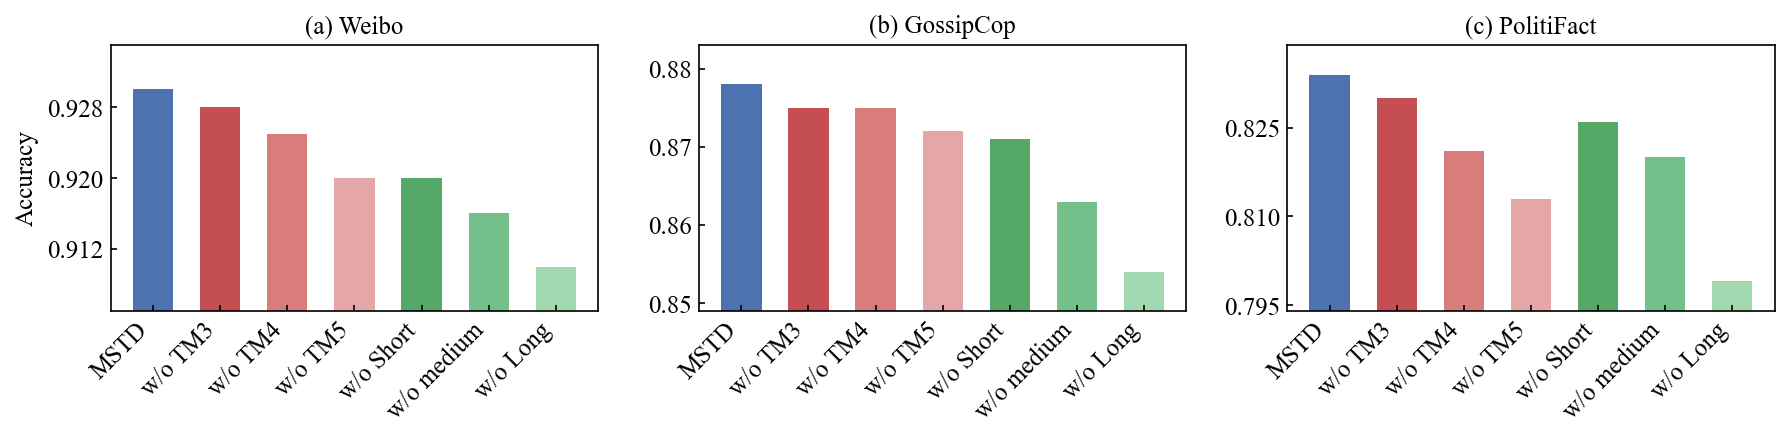

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 控制刻度疏密

# ============ 1. 读取数据 ============
csv_path = r'ALL_DATASETS_识别结果汇总.csv'

df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# ============ 2. 准备顺序 ============
dataset_order = ['Weibo', 'GossipCop', 'PolitiFact']

folder_map = {
    'MSTD':      'MSTD',
    'w/o TM3':   '30off',
    'w/o TM4':   '40off',
    'w/o TM5':   '50off',
    'w/o Short': 'short',
    'w/o Inter': 'inter',
    'w/o Long':  'long',
}
df['Method'] = df['Folder'].map(folder_map)

method_order = ['MSTD', '30off', '40off', '50off',
                'short', 'inter', 'long']

# x 轴显示用标签
label_map = {
    'MSTD':  'MSTD',
    '30off': 'w/o TM3',
    '40off': 'w/o TM4',
    '50off': 'w/o TM5',
    'short': 'w/o Short',
    'inter': 'w/o medium',   # ← 这里改成 w/o medium
    'long':  'w/o Long',
}

# ============ 3. 配色设计 ============
# MSTD：蓝色
# w/o TM3–TM5：同一红系由深到浅
# w/o Short–Long：同一绿系由深到浅
method_colors = {
    'MSTD':  '#4C72B0',  # 蓝

    '30off': '#C44E52',  # 深红
    '40off': '#D97C7C',  # 中红
    '50off': '#E4A6A6',  # 浅红

    'short': '#55A868',  # 深绿
    'inter': '#73C08A',  # 中绿
    'long':  '#A2D9B1',  # 浅绿
}

# ============ 4. 全局样式 ============
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.family': 'Times New Roman',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
    'axes.unicode_minus': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============ 5. 绘图 ============
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, dataset in enumerate(dataset_order):
    ax = axes[i]
    sub = df[df['Dataset'] == dataset]

    accs, labels, cols = [], [], []
    for m in method_order:
        row = sub[sub['Method'] == m]
        if not row.empty:
            accs.append(float(row['Accuracy'].values[0]))
            labels.append(label_map[m])
            cols.append(method_colors[m])

    x = np.arange(len(accs))
    ax.bar(
        x, accs,
        color=cols,
        width=0.6,
        edgecolor='none',
        linewidth=0.0
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)

    if i == 0:
        ax.set_ylabel('Accuracy', fontsize=12)

    tag = chr(ord('a') + i)
    ax.set_title(f'({tag}) {dataset}', fontsize=12)

    ymin = min(accs) - 0.005
    ymax = max(accs) + 0.005
    ax.set_ylim(ymin, ymax)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout(w_pad=2.0, h_pad=0.8)

save_path = r'Fig9.pdf'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

